# Presentation v3

In [152]:
from adjustText import adjust_text
from cmapPy.pandasGEXpress import parse
import hdbscan
import itertools
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import random
import seaborn as sns
import scipy.spatial.distance as ssd
import scipy.cluster.hierarchy as sch
from scipy.stats import zscore
from tqdm import tqdm
import umap.umap_ as umap
from upsetplot import generate_counts, plot, from_indicators, UpSet

import torch
from torch.nn import Linear, ReLU, Sequential
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Batch
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from torch_geometric.utils import from_networkx

In [2]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
OUTPUT = 'D:/DDesktop/_work/data/canada/output/'

GRAPH = 'D:/DDesktop/_work/graphs/canada/'
CONTEXT = 'D:/DDesktop/_work/graphs/canada/context/'
HYPER = 'D:/DDesktop/_work/graphs/canada/hypertension/'

In [3]:
def graph_edge_weights(graph: nx.Graph, modifier: int = 1, report: bool = False) -> list:
    '''
    Extracts edge weight values of a NetworkX graph object to a list. A modifier converts the values for visualisation.
    '''

    weights = [graph[source][target]['weight'] / modifier for source, target, attr in graph.edges(data = True)]

    if report == True:
        num_entries = len(weights)
        print('>> graph_edge_getweights')
        print(f'Weights extracted for {num_entries:,} edges w/ a modifier of {modifier:,}')
        print()

    return weights

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()


# Analysis

In [4]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')
# Get perturbagen IDs
list_known_names = ['imatinib', 'agatolimod', 'pentoxifylline', 'mefloquine', 'rosiglitazone', 'imiquimod', 'acetaminophen', 'agatolimod sodium']
list_known_ids = [df_lincs_perturbagens['perturbagen_id'][df_lincs_perturbagens['perturbagen_name'] == name].values[0] for name in list_known_names if name in df_lincs_perturbagens['perturbagen_name'].values]
# Set mefloquine ID
mefloquine_id = 'BRD-K40645748'

In [5]:
# Initialise graph list
pyg_graphs = []

# Iterate through files
for graph in tqdm(os.listdir(CONTEXT), desc = 'Converting context graphs to PyG objects', total = len(os.listdir(CONTEXT))):
    
    # Get perturbagen id
    perturbagen_id = graph.split('_')[1]
    
    # Load data
    G = pickle_load(CONTEXT + graph)
    # Iterate through nodes
    for node in G.nodes:
        G.nodes[node]['x'] = [G.nodes[node]['dexp']]
    
    # Convert to PyG object
    pyg = from_networkx(G)
    pyg.x = pyg.x.float()
    # Add perturbagen ID as name
    pyg.name = f'{perturbagen_id}'
    pyg_graphs.append(pyg)

Converting context graphs to PyG objects: 100%|██████████| 505/505 [02:26<00:00,  3.44it/s]


In [ ]:
# Define untrained GIN encoder
class GINEncoder(torch.nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        nn1 = Sequential(Linear(1, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        nn2 = Sequential(Linear(hidden_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = Linear(hidden_dim, hidden_dim)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = global_add_pool(x, batch)
        return self.lin(x)

print('Untrained GIN encoder complete')

# Instantiate model
encoder = GINEncoder()
encoder.eval()

print('Model instantiated')

# Generate embeddings w/o training
embeddings = []
with torch.no_grad():
    for graph in tqdm(pyg_graphs, desc = 'Generating embeddings', total = len(pyg_graphs)):
        batch = torch.zeros(graph.x.size(0), dtype=torch.long)  # single graph batch
        emb = encoder(graph.x, graph.edge_index, batch)
        embeddings.append(emb.squeeze())

# Extract embedding matrix
embedding_matrix = torch.stack(embeddings).numpy()

Untrained GIN encoder complete
Model instantiated


Generating embeddings: 100%|██████████| 505/505 [00:00<00:00, 986.58it/s] 


## Uncentered

In [ ]:
# Normalise embedding values
normalised_embeddings = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Initialise dataframe
df_cosine = pd.DataFrame()

# Iterate through IDs
for id in list_known_ids:
    
    # Find index in pyg_graphs
    ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == id)
    
    # Calculate cosine similarity
    sims = cosine_similarity([normalised_embeddings[ref_idx]], normalised_embeddings)[0]
    # Sort values 
    sims_sort = np.sort(sims)[::-1]
    # Sort by closest similarity
    similarity = sims.argsort()[::-1]
    # Get graph IDs
    similar_ids = [pyg_graphs[i].name for i in similarity]
    # Convert to dataframe
    df_id = pd.DataFrame(similar_ids, columns = ['perturbagen_id'])
    # Merge
    df_id = pd.merge(df_id, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Add column
    df_id['value'] = sims_sort
    # Add ref column
    df_id['ref_id'] = id
    df_id['ref_name'] = df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == id].values[0]
    # Concatenate
    df_cosine = pd.concat([df_cosine, df_id])

df_cosine.head()

,perturbagen_id,perturbagen_name,value,ref_id,ref_name
0,BRD-K92723993,imatinib,1.000000,BRD-K92723993,imatinib
1,BRD-K40645748,mefloquine,0.999888,BRD-K92723993,imatinib
2,BRD-A69917777,aminopentamide,0.999841,BRD-K92723993,imatinib
3,BRD-K15409150,penfluridol,0.999778,BRD-K92723993,imatinib
4,BRD-A95445494,maackiain,0.999759,BRD-K92723993,imatinib


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\roman\AppData\Local\Temp\ipykernel_18228\3150454391.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice.sort_values(by = 'value', ascending = False, inplace = True)


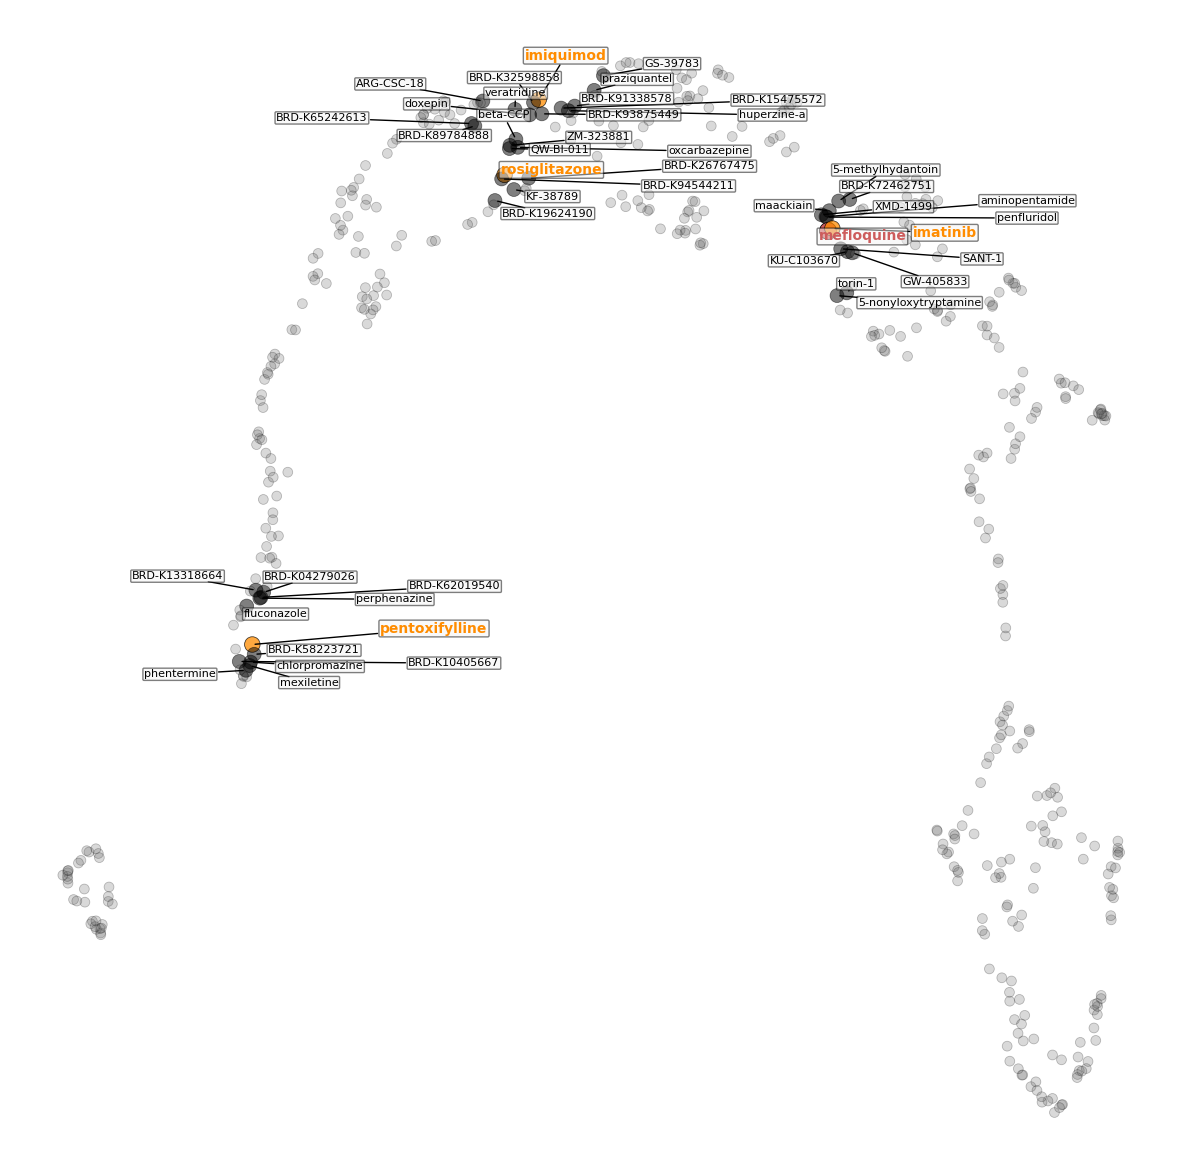

In [21]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Normalise embedding values
normalised_embeddings = embedding_matrix / np.linalg.norm(embedding_matrix, axis=1, keepdims=True)

# Instantiate model
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(normalised_embeddings)
graph_ids = [g.name for g in pyg_graphs]
# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_id'] = graph_ids
# Merge
df_plot = pd.merge(df_plot, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')

# Initialise list
list_highlight = []

# Iterate through df_cosine
for ref_id in pd.unique(df_cosine['ref_id']):
    # Slice dataframe
    df_slice = df_cosine[df_cosine['ref_id'] == ref_id]
    # Sort values
    df_slice.sort_values(by = 'value', ascending = False, inplace = True)
    # Get top 10 closest
    list_slice_highlight = df_slice['perturbagen_id'].iloc[1:11].tolist()
    # Add to list_highlight
    list_highlight.extend(list_slice_highlight)

# Set colors
colors = ['indianred' if g.name == mefloquine_id else 'darkorange' if g.name in list_known_ids else 'black' if g.name in list_highlight else 'dimgrey' for g in pyg_graphs]
sizes = [150 if g.name == mefloquine_id else 125 if g.name in list_known_ids else 100 if g.name in list_highlight else 50 for g in pyg_graphs]
alphas = [1 if g.name == mefloquine_id else 0.75 if g.name in list_known_ids else 0.5 if g.name in list_highlight else 0.25 for g in pyg_graphs]

plt.figure(figsize=(15, 15))
plt.axis('off')
sns.scatterplot(df_plot, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = sizes, alpha = alphas);

# Label styling
mef_style = {
    'fontsize': 10,
    'weight' : 'bold',
    'color': 'indianred',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

known_style = {
    'fontsize': 10,
    'weight' : 'bold',
    'color': 'darkorange',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

highlight_style = {
    'fontsize': 8,
    'weight' : 'normal',
    'color': 'black',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

other_style = {
    'fontsize': 10,
    'alpha' : 0.25,
    'weight' : 'bold',
    'color': 'dimgrey',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.25,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

highlight_texts = []
texts = []

for id in pd.unique(df_plot['perturbagen_id']):
    df_slice = df_plot[df_plot['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]
    if id == mefloquine_id:
        highlight_texts.append(plt.text(x, y, label, **mef_style));
    elif id in list_known_ids:
        highlight_texts.append(plt.text(x, y, label, **known_style));
    elif id in list_highlight:
        highlight_texts.append(plt.text(x, y, label, **highlight_style));
    # else:
    #     texts.append(plt.text(x, y, label, **other_style));
    
# adjust_text(texts,
#             arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
#             expand = (1,1));

adjust_text(highlight_texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 1),
            expand = (1.5,1.5));

plt.show()

### Clustering

In [36]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=8)
labels = clusterer.fit_predict(embedding_2d)
df_plot['cluster'] = labels

num_clusters = len(pd.unique(df_plot['cluster']))
print(f'{num_clusters} clusters identified')

df_plot.head()

2 clusters identified


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x,y,perturbagen_id,perturbagen_name,cluster
0,10.664188,5.470164,BRD-A00474148,BRD-A00474148,1
1,4.807742,7.790607,BRD-A01593789,chlormadinone-acetate,1
2,9.462682,5.108855,BRD-A01826957,xanthinol,1
3,5.042458,7.510742,BRD-A02006392,nitrendipine,1
4,10.641665,4.339401,BRD-A04706586,bucladesine,1


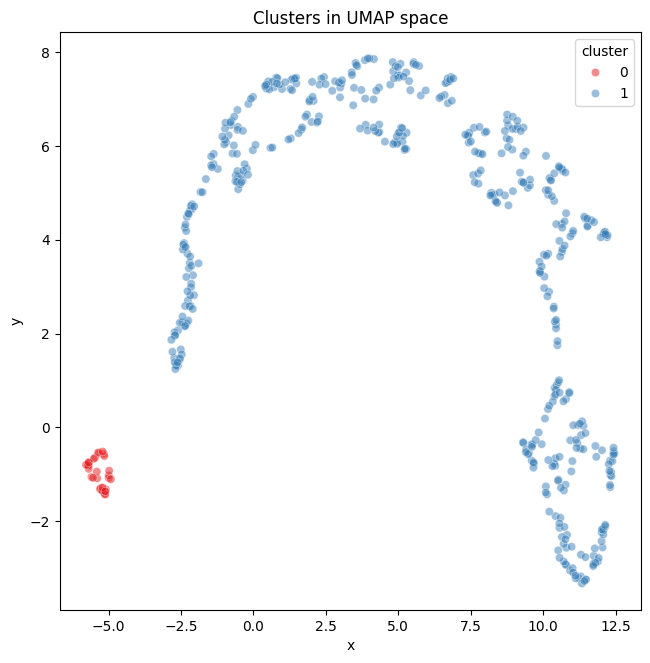

In [38]:
plt.figure(figsize = (7.5,7.5))
sns.scatterplot(df_plot[df_plot['cluster'] != -1], x='x', y='y', hue='cluster', palette='Set1', alpha = 0.5)
#sns.scatterplot(df_representatives, x = 'x', y = 'y', hue = 'cluster', palette='tab10', edgecolors = 'black', s = 200, legend = False)
plt.title("Clusters in UMAP space")
plt.show()

In [24]:
# Initialise dataframe
df_mean = pd.DataFrame()

# Get number of clusters
cluster_ids = list(pd.unique(df_plot['cluster']))
cluster_ids = [entry for entry in cluster_ids if entry >= 0]

# Iterate through clusters
for cluster in tqdm(cluster_ids, desc = 'Getting cluster expression', total = len(cluster_ids)):
    # Slice dataframe
    df_slice = df_plot[df_plot['cluster'] == cluster]
    # Extract perturbagen IDs
    list_slice_ids = list(pd.unique(df_slice['perturbagen_id']))

    # Initialise dataframe
    df_cluster = pd.DataFrame()

    # Iterate through slice IDs
    for id in list_slice_ids:
        # Load graph
        G = pickle_load(CONTEXT + f'HT29_{id}_10_6H.pkl')
        # Get expression values
        vals = [(node, G.nodes[node]['dexp']) for node in G.nodes]
        # Convert to dataframe
        df_vals = pd.DataFrame(vals, columns = ['node', 'dexp'])
        # Add column
        df_vals['id'] = id
        # Concatenate
        df_cluster = pd.concat([df_cluster, df_vals])
    
    # Group data
    df_cluster = df_cluster[['node', 'dexp']].groupby(by = ['node']).mean()
    # Reset index
    df_cluster.reset_index(inplace = True)
    # Add cluster column
    df_cluster['cluster'] = cluster
    # Concatenate
    df_mean = pd.concat([df_mean, df_cluster])

df_mean.head()

Getting cluster expression: 100%|██████████| 2/2 [00:05<00:00,  2.66s/it]


,node,dexp,cluster
0,ABCB6,0.225936,1
1,ABCC5,0.551679,1
2,ABCF1,0.026999,1
3,ABCF3,-0.201681,1
4,ABHD4,0.580734,1


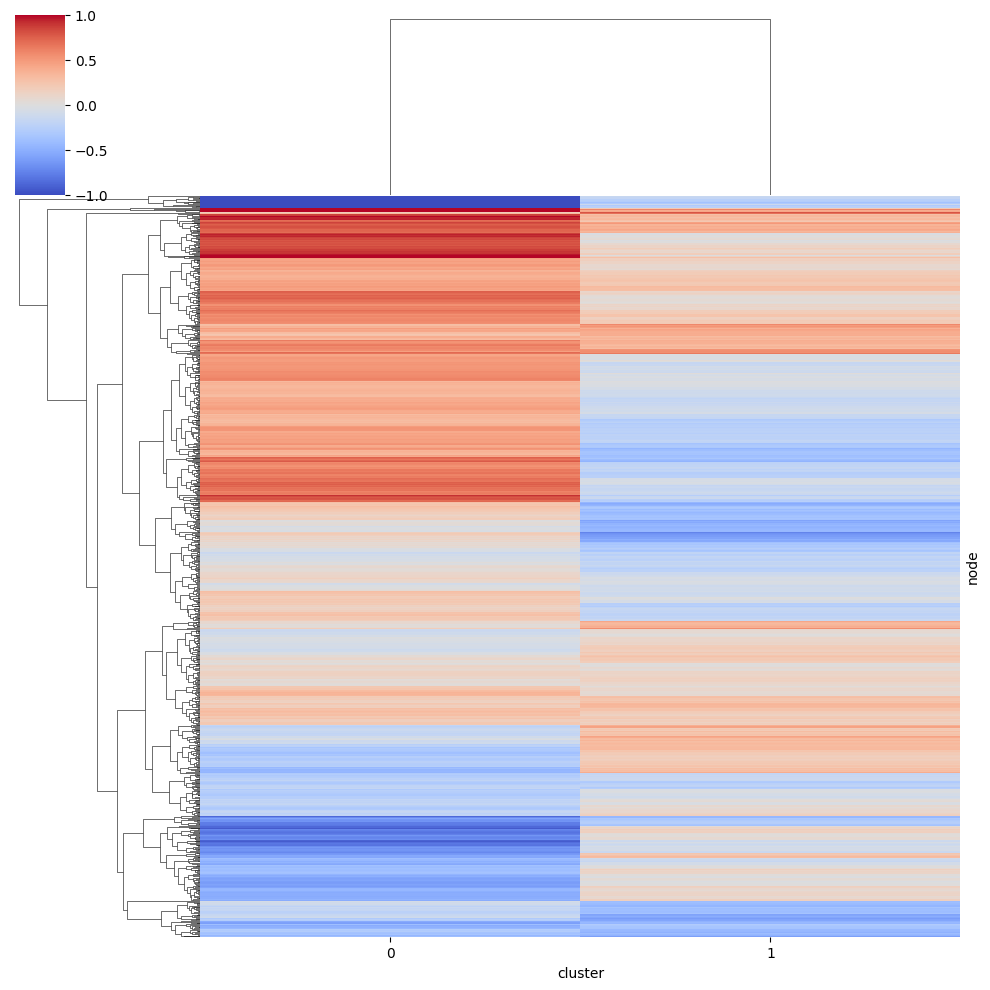

In [39]:
df_hm = pd.pivot(df_mean, index = 'node', columns = 'cluster', values = 'dexp')
sns.clustermap(df_hm, cmap = 'coolwarm', vmin = -1, vmax = 1, yticklabels = False)

### Representatives

In [ ]:
# DataFrame to store representative points
representatives = []

for label, group in df_plot.groupby('cluster'):
    if label == -1:
        continue  # skip noise cluster if needed
    centroid = group[['x', 'y']].mean().values
    distances = np.linalg.norm(group[['x', 'y']].values - centroid, axis=1)
    closest_idx = group.index[np.argmin(distances)]
    representatives.append(df_plot.loc[closest_idx])
    
df_representatives = pd.DataFrame(representatives)
df_representatives.head()

In [ ]:
plt.figure(figsize = (7.5,7.5))
sns.scatterplot(df_plot[df_plot['cluster'] != -1], x='x', y='y', hue='cluster', palette='tab10', alpha = 0.5)
sns.scatterplot(df_representatives, x = 'x', y = 'y', hue = 'cluster', palette='tab10', edgecolors = 'black', s = 200, legend = False)
plt.title("Clusters in UMAP space")
plt.show()

## Centered

In [ ]:
# Subtract mean vector and center matrix
centered = embedding_matrix - embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
centered = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Initialise dataframe
df_centered = pd.DataFrame()

# Iterate through IDs
for id in list_known_ids:
    # Find index in pyg_graphs
    ref_idx = next(i for i, g in enumerate(pyg_graphs) if g.name == id)
    
    # Calculate cosine similarity
    sims = cosine_similarity([centered[ref_idx]], centered)[0]
    # Sort values 
    sims_sort = np.sort(sims)[::-1]
    # Sort by closest similarity
    similarity = sims.argsort()[::-1]
    # Get graph IDs
    similar_ids = [pyg_graphs[i].name for i in similarity]
    # Convert to dataframe
    df_id = pd.DataFrame(similar_ids, columns = ['perturbagen_id'])
    # Merge
    df_id = pd.merge(df_id, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')
    # Add column
    df_id['value'] = sims_sort
    # Add ref column
    df_id['ref_id'] = id
    df_id['ref_name'] = df_lincs_perturbagens['perturbagen_name'][df_lincs_perturbagens['perturbagen_id'] == id].values[0]
    # Concatenate
    df_centered = pd.concat([df_centered, df_id])

df_centered.head()

,perturbagen_id,perturbagen_name,value,ref_id,ref_name
0,BRD-K92723993,imatinib,1.000000,BRD-K92723993,imatinib
1,BRD-K40645748,mefloquine,0.989946,BRD-K92723993,imatinib
2,BRD-A55946879,BW-B70C,0.987147,BRD-K92723993,imatinib
3,BRD-K68407802,KIN001-055,0.984788,BRD-K92723993,imatinib
4,BRD-A69917777,aminopentamide,0.984033,BRD-K92723993,imatinib


In [111]:
df_filter = df_centered[df_centered['ref_name'] == 'mefloquine'].sort_values(by = 'value', ascending = False).head(11)
df_filter = df_filter.iloc[1:11,:]
df_filter

,perturbagen_id,perturbagen_name,value,ref_id,ref_name
1,BRD-K92723993,imatinib,0.989946,BRD-K40645748,mefloquine
2,BRD-K83637872,SANT-1,0.985880,BRD-K40645748,mefloquine
3,BRD-A81389811,BRD-A81389811,0.972683,BRD-K40645748,mefloquine
4,BRD-A55946879,BW-B70C,0.965309,BRD-K40645748,mefloquine
5,BRD-K22010301,JLK-6,0.964306,BRD-K40645748,mefloquine
6,BRD-K98143437,SB-239063,0.962681,BRD-K40645748,mefloquine
7,BRD-K68407802,KIN001-055,0.960537,BRD-K40645748,mefloquine
8,BRD-A09925278,etilefrine,0.958221,BRD-K40645748,mefloquine
9,BRD-K91442916,CAM-9-026,0.956880,BRD-K40645748,mefloquine
10,BRD-A08003242,rhodomyrtoxin-b,0.955022,BRD-K40645748,mefloquine


In [116]:
df_opentargets = pickle_load(OUTPUT + 'df_opentargets.pkl')
df_opentargets = df_opentargets[df_opentargets['drug_name'].isin(pd.unique(df_filter['perturbagen_name']))]
df_opentargets.drop_duplicates(subset = ['drug_name', 'moa'], inplace = True)
df_opentargets

,drug_id,drug_name,drug_type,moa,moa_type,target_symbol,target_name,trial_phase,trial_status,source
16,CHEMBL941,imatinib,Small molecule,Tyrosine-protein kinase ABL inhibitor,NaN,ABL1,"ABL proto-oncogene 1, non-receptor tyrosine ki...",2.0,Unknown status,https://clinicaltrials.gov/study/NCT03697668
30,CHEMBL941,imatinib,Small molecule,Platelet-derived growth factor receptor beta i...,NaN,PDGFRB,platelet derived growth factor receptor beta,2.0,Unknown status,https://clinicaltrials.gov/study/NCT03697668
31,CHEMBL941,imatinib,Small molecule,Stem cell growth factor receptor inhibitor,NaN,KIT,"KIT proto-oncogene, receptor tyrosine kinase",2.0,Unknown status,https://clinicaltrials.gov/study/NCT03697668
32,CHEMBL941,imatinib,Small molecule,Bcr/Abl fusion protein,NaN,BCR,BCR activator of RhoGEF and GTPase,2.0,Unknown status,https://clinicaltrials.gov/study/NCT03697668


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\roman\AppData\Local\Temp\ipykernel_18228\1953134489.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice.sort_values(by = 'value', ascending = False, inplace = True)


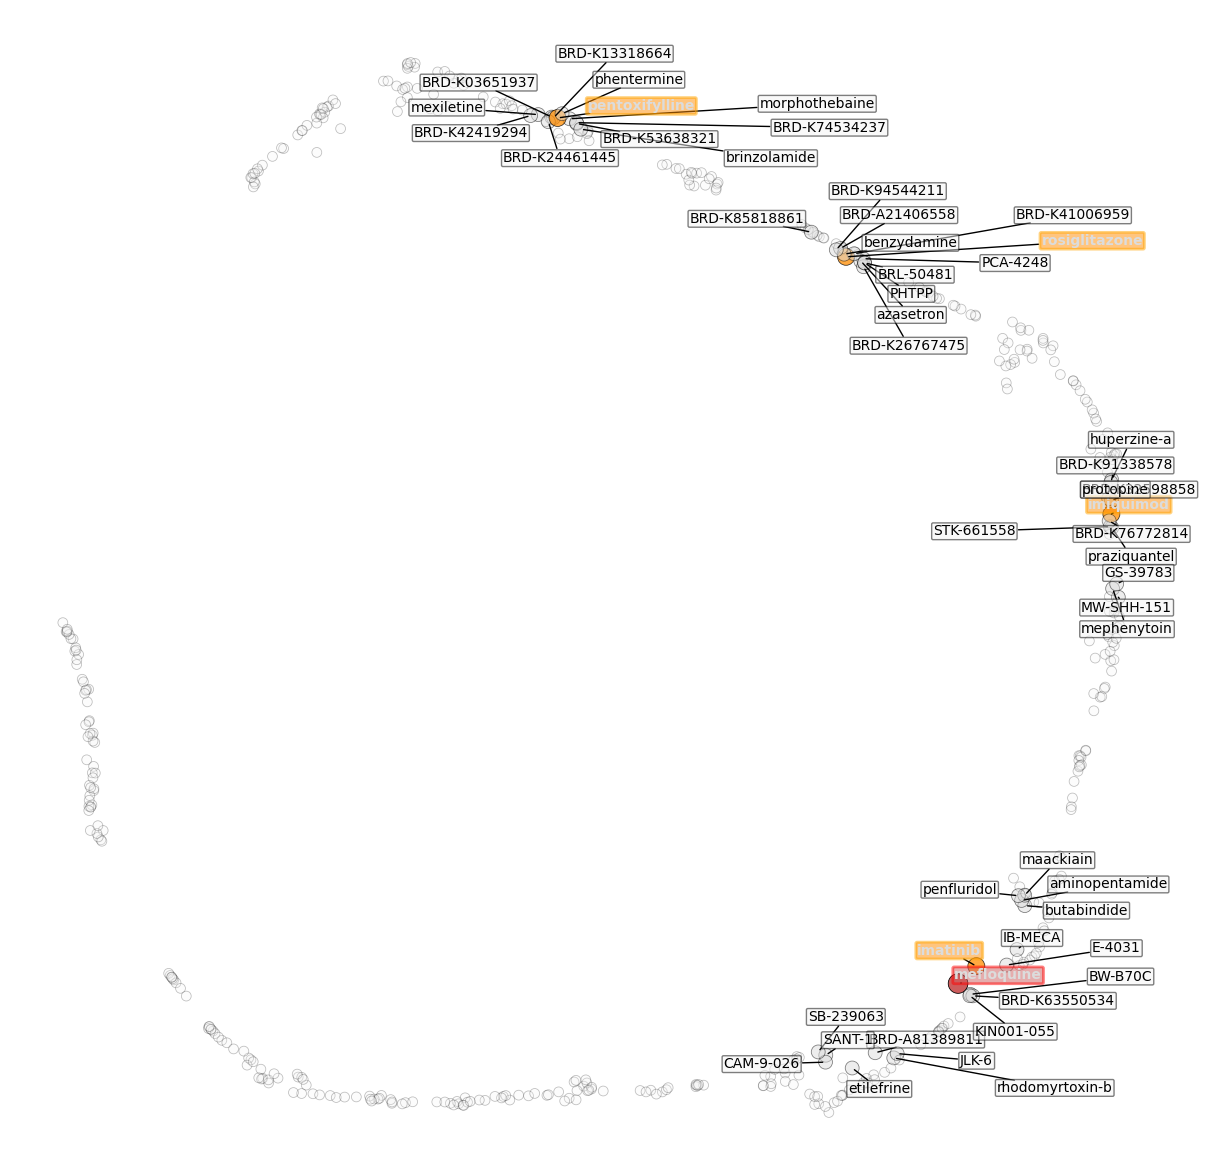

In [ ]:
# Load data
df_lincs_perturbagens = pickle_load(OUTPUT + 'df_lincs_perturbagens.pkl')

# Subtract mean vector and center matrix
centered = embedding_matrix - embedding_matrix.mean(axis=0, keepdims=True)
# Normalise centered values
normalised_embeddings = centered / np.linalg.norm(centered, axis=1, keepdims=True)

# Instantiate model
reducer = umap.UMAP(n_components=2, random_state=42, spread = 1)
embedding_2d = reducer.fit_transform(normalised_embeddings)
graph_ids = [g.name for g in pyg_graphs]
# Convert to dataframe
df_plot = pd.DataFrame(embedding_2d, columns = ['x', 'y'])
df_plot['perturbagen_id'] = graph_ids
# Merge
df_plot = pd.merge(df_plot, df_lincs_perturbagens, on = 'perturbagen_id', how = 'left')

# Initialise list
list_highlight = []

# Iterate through df_centered
for ref_id in pd.unique(df_centered['ref_id']):
    # Slice dataframe
    df_slice = df_centered[df_centered['ref_id'] == ref_id]
    # Sort values
    df_slice.sort_values(by = 'value', ascending = False, inplace = True)
    # Get top 10 closest
    list_slice_highlight = df_slice['perturbagen_id'].iloc[1:11].tolist()
    # Add to list_highlight
    list_highlight.extend(list_slice_highlight)

# Set colors
# Set colors
colors = ['indianred' if g.name == mefloquine_id else 'darkorange' if g.name in list_known_ids else 'gainsboro' if g.name in list_highlight else 'whitesmoke' for g in pyg_graphs]
sizes = [200 if g.name == mefloquine_id else 150 if g.name in list_known_ids else 100 if g.name in list_highlight else 50 for g in pyg_graphs]
alphas = [1 if g.name == mefloquine_id else 0.75 if g.name in list_known_ids else 0.5 if g.name in list_highlight else 0.25 for g in pyg_graphs]

plt.figure(figsize=(15, 15))
plt.axis('off')
sns.scatterplot(df_plot, x = 'x', y = 'y', c = colors, edgecolors = 'black', s = sizes, alpha = alphas);

# Label styling
mefloquine_style = {
    'fontsize': 10,
    'weight' : 'bold',
    'color': 'gainsboro',
    'bbox': {
        'facecolor': 'indianred',
        'alpha': 0.5,
        'edgecolor': 'red',
        'linewidth' : 2,
        'boxstyle': 'round,pad=0.1'
    }
}

malarial_style = {
    'fontsize': 10,
    'weight' : 'bold',
    'color': 'gainsboro',
    'bbox': {
        'facecolor': 'darkorange',
        'alpha': 0.5,
        'edgecolor': 'orange',
        'linewidth' : 2,
        'boxstyle': 'round,pad=0.1'
    }
}

highlight_style = {
    'fontsize': 10,
    'weight' : 'normal',
    'color': 'black',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

other_style = {
    'fontsize': 8,
    'alpha' : 0.25,
    'weight' : 'bold',
    'color': 'dimgrey',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.25,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

highlight_texts = []
texts = []

for id in pd.unique(df_plot['perturbagen_id']):
    df_slice = df_plot[df_plot['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]
    if id == mefloquine_id:
        highlight_texts.append(plt.text(x, y, label, **mefloquine_style));
    elif id in list_known_ids:
        highlight_texts.append(plt.text(x, y, label, **malarial_style));
    elif id in list_highlight:
        highlight_texts.append(plt.text(x, y, label, **highlight_style));
    # else:
    #     texts.append(plt.text(x, y, label, **other_style));
    
# adjust_text(texts,
#             arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
#             expand = (1,1));

adjust_text(highlight_texts,
            arrowprops=dict(arrowstyle='-', color='black', lw = 1),
            expand = (1.5,1.5));
plt.savefig(OUTPUT + 'umap_plot.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [118]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
labels = clusterer.fit_predict(embedding_2d)
df_plot['cluster'] = labels

num_clusters = len(pd.unique(df_plot['cluster']))
print(f'{num_clusters} clusters identified')

df_plot.head()

8 clusters identified


c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x,y,perturbagen_id,perturbagen_name,cluster
0,12.642774,1.464598,BRD-A00474148,BRD-A00474148,3
1,14.069789,6.289340,BRD-A01593789,chlormadinone-acetate,5
2,8.365705,-0.331155,BRD-A01826957,xanthinol,3
3,13.971209,6.428676,BRD-A02006392,nitrendipine,5
4,8.604405,-0.364432,BRD-A04706586,bucladesine,3


In [119]:
# DataFrame to store representative points
representatives = []

for label, group in df_plot.groupby('cluster'):
    if label == -1:
        continue  # skip noise cluster if needed
    centroid = group[['x', 'y']].mean().values
    distances = np.linalg.norm(group[['x', 'y']].values - centroid, axis=1)
    closest_idx = group.index[np.argmin(distances)]
    representatives.append(df_plot.loc[closest_idx])
    
df_representatives = pd.DataFrame(representatives)
df_representatives.head(10)

,x,y,perturbagen_id,perturbagen_name,cluster
339,-3.716521,4.878494,BRD-K55630727,BRD-K55630727,0
430,2.213764,14.606883,BRD-K80970344,pyrrolidine-dithiocarbamate,1
186,1.786260,-0.791549,BRD-K17894950,indirubin,2
173,10.901793,0.235668,BRD-K15601958,SEW-2871,3
416,9.363496,12.441541,BRD-K76425766,BRD-K76425766,4
267,14.043137,6.339861,BRD-K37061750,BRD-K37061750,5
23,13.134833,10.489519,BRD-A18579359,wiskostatin,6


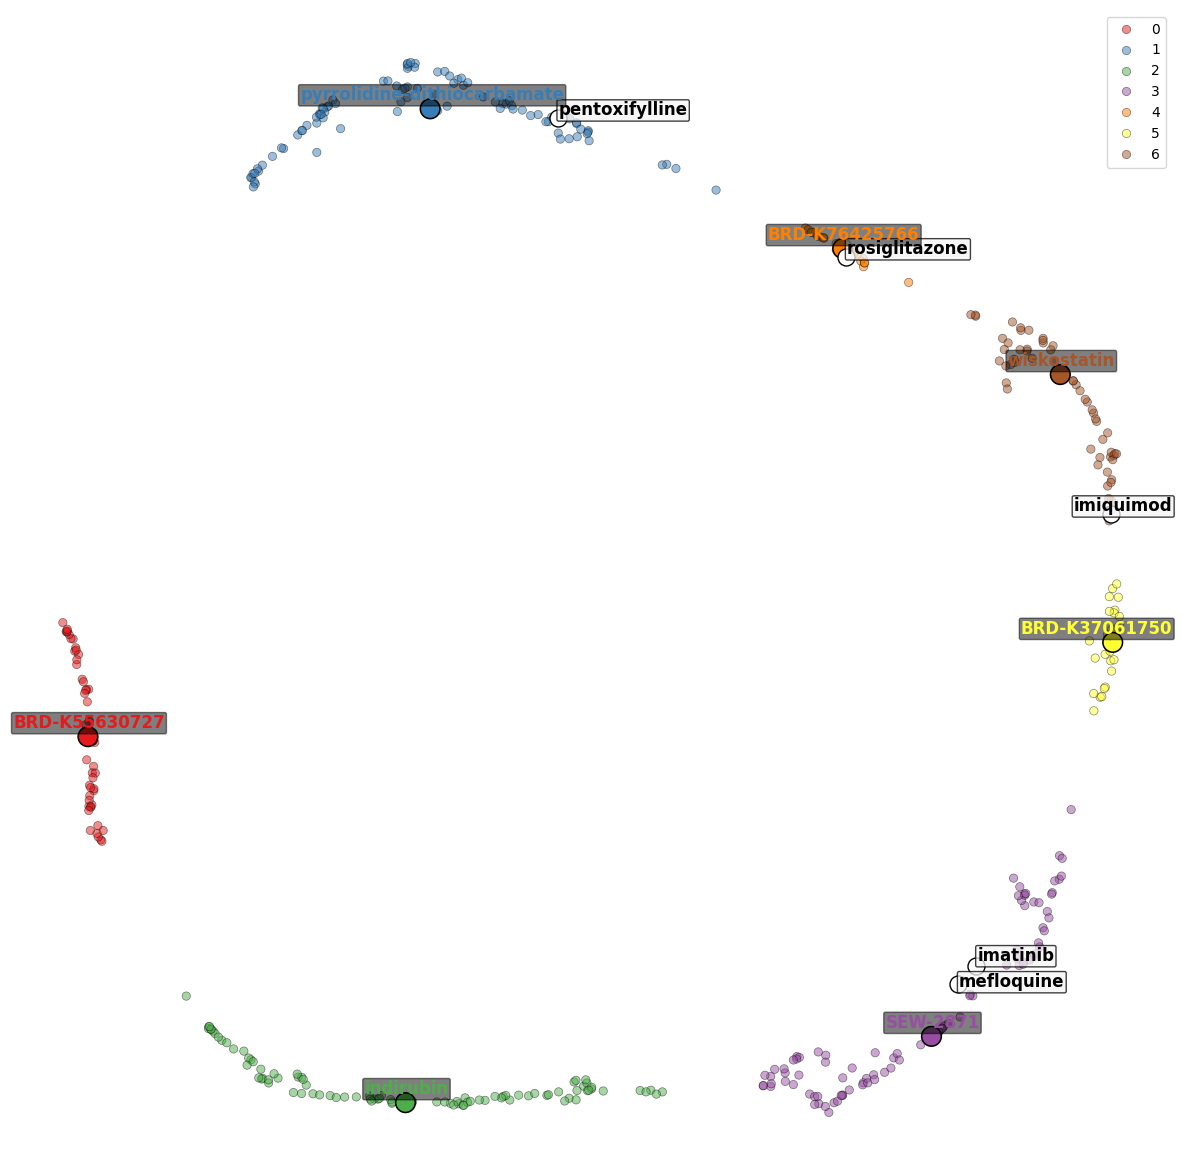

In [ ]:
plt.figure(figsize = (15,15))
plt.axis('off')
sns.scatterplot(df_plot[df_plot['cluster'] != -1], x='x', y='y', hue='cluster', palette='Set1', alpha = 0.5, edgecolors = 'black')
sns.scatterplot(df_representatives, x = 'x', y = 'y', hue = 'cluster', palette='Set1', edgecolors = 'black', s = 200, legend = False)
sns.scatterplot(df_plot[df_plot['perturbagen_id'].isin(list_known_ids)], x = 'x', y = 'y', c = 'white', s = 150, alpha = 1, edgecolors = 'black')
#plt.title("Clustering")

label_style = {
    'fontsize': 12,
    'alpha' : 1,
    'weight' : 'bold',
    'color': 'black',
    'bbox': {
        'facecolor': 'whitesmoke',
        'alpha': 0.75,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
    }
}

texts = []
rep_texts = []

for id in list_known_ids:
    df_slice = df_plot[df_plot['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]
    texts.append(plt.text(x, y, label, **label_style));

# Get first n colors from Set1 palette
n = 10
palette_colors = list(sns.color_palette('Set1', n_colors=n))

for id, colour in zip(pd.unique(df_representatives['perturbagen_id']), palette_colors):
    df_slice = df_representatives[df_representatives['perturbagen_id'] == id]
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    label = df_slice['perturbagen_name'].values[0]

    rep_style = {
    'fontsize': 12,
    'alpha' : 1,
    'weight' : 'bold',
    'color': colour,
    'ha': 'center',             
    'va': 'bottom',             
    'bbox': {
        'facecolor': 'black',
        'alpha': 0.5,
        'edgecolor': 'black',
        'boxstyle': 'round,pad=0.1'
        }
    }

    rep_texts.append(plt.text(x, y, label, **rep_style));

    
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
            expand = (1,1));

adjust_text(rep_texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25),
            #expand = (0.5,0.5)
            );

plt.savefig(OUTPUT + 'umap_plot_clusters.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [69]:
graph_lm = pickle_load(GRAPH + 'graph_lm.pkl', report = True)
graph_base = pickle_load(GRAPH + 'graph_base.pkl', report = True)
df_string_info = pickle_load(OUTPUT + 'df_string_info.pkl')
df_filter = df_string_info[df_string_info['string_name'].isin(graph_lm.nodes)]
df_filter.head()

>> pickle_load
Pickled graph loaded w/ 921 nodes and 8,738 edges

>> pickle_load
Pickled graph loaded w/ 18,767 nodes and 738,805 edges



,id,string_name,string_desc
2,ENSP00000001008,FKBP4,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
15,ENSP00000005257,RALA,Ras-related protein Ral-A; Multifunctional GTP...
25,ENSP00000006275,TRAPPC6A,Trafficking protein particle complex subunit 6...
42,ENSP00000011473,SYPL1,Synaptophysin-like protein 1; Synaptophysin li...
48,ENSP00000013070,UBR7,Putative E3 ubiquitin-protein ligase UBR7; E3 ...


In [81]:
#df_string_info[df_string_info['string_name'].str.contains('BCR')]
df_string_info[df_string_info['string_desc'].str.contains('BCR-ABL')]

,id,string_name,string_desc
4436,ENSP00000295797,PRKCI,Protein kinase C iota type; Calcium- and diacy...


In [136]:
# Initialise dataframe
df_mean = pd.DataFrame()

# Get number of clusters
cluster_ids = list(pd.unique(df_plot['cluster']))
cluster_ids = [entry for entry in cluster_ids if entry >= 0]

# Iterate through clusters
for cluster in tqdm(cluster_ids, desc = 'Getting cluster expression', total = len(cluster_ids)):
    # Slice dataframe
    df_slice = df_plot[df_plot['cluster'] == cluster]
    # Extract perturbagen IDs
    list_slice_ids = list(pd.unique(df_slice['perturbagen_id']))

    # Initialise dataframe
    df_cluster = pd.DataFrame()

    # Iterate through slice IDs
    for id in list_slice_ids:
        # Load graph
        G = pickle_load(CONTEXT + f'HT29_{id}_10_6H.pkl')
        # Get expression values
        vals = [(node, G.nodes[node]['dexp']) for node in G.nodes]
        # Convert to dataframe
        df_vals = pd.DataFrame(vals, columns = ['node', 'dexp'])
        # Add column
        df_vals['id'] = id
        # Concatenate
        df_cluster = pd.concat([df_cluster, df_vals])
    
    # Group data
    df_cluster = df_cluster[['node', 'dexp']].groupby(by = ['node']).mean()
    # Reset index
    df_cluster.reset_index(inplace = True)
    # Add cluster column
    df_cluster['cluster'] = cluster
    # Concatenate
    df_mean = pd.concat([df_mean, df_cluster])

df_mean.head()

Getting cluster expression: 100%|██████████| 7/7 [00:06<00:00,  1.14it/s]


,node,dexp,cluster
0,ABCB6,0.137762,3
1,ABCC5,0.193812,3
2,ABCF1,0.020072,3
3,ABCF3,-0.257859,3
4,ABHD4,0.398201,3


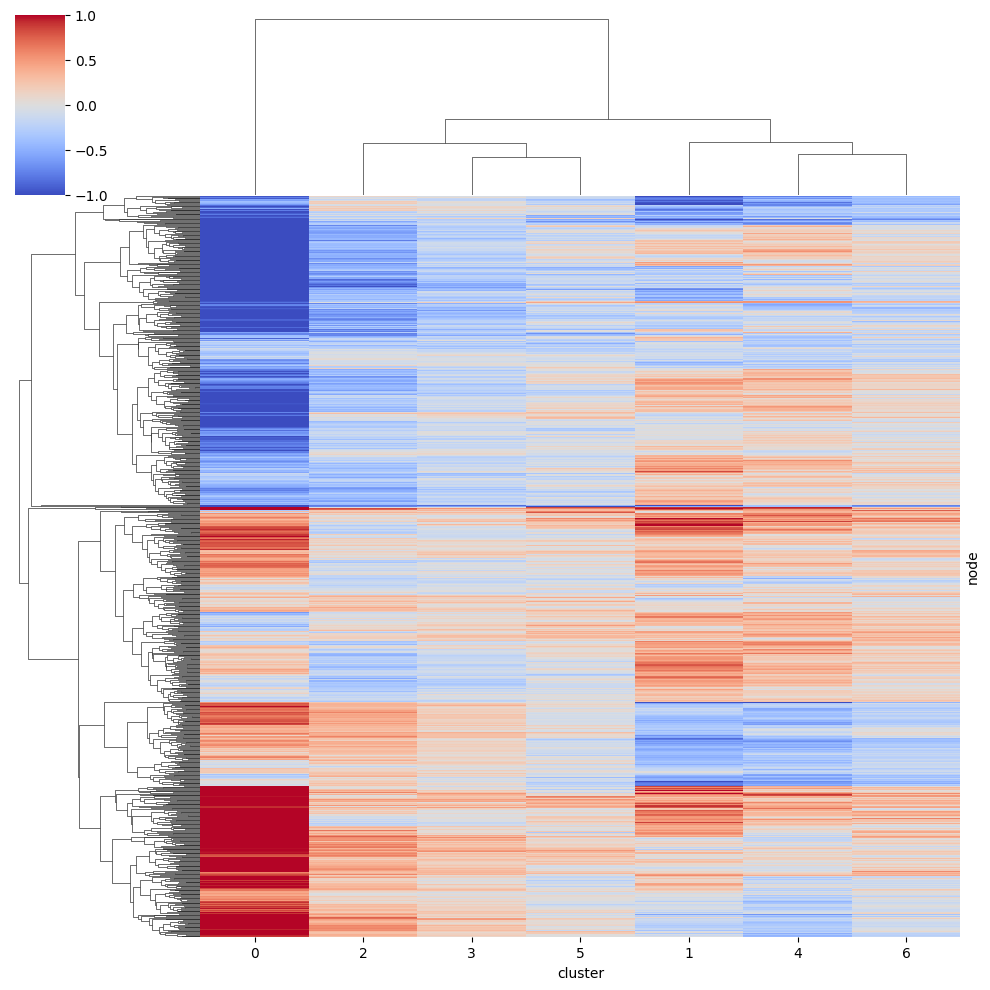

In [186]:
df_hm = pd.pivot(df_mean, index = 'node', columns = 'cluster', values = 'dexp')
sns.clustermap(df_hm, cmap = 'coolwarm', vmin = -1, vmax = 1, yticklabels = False)

In [188]:
df_sub = df_hm[3]
df_residual = df_sub - df_hm.mean(axis = 1)

# Sort to find genes most up/down-regulated in Drug_A context
most_unique_genes = df_residual.sort_values(ascending=False)
n = 50
list_residual_ureg = list(most_unique_genes.head(n).index.values)
list_residual_dreg = list(most_unique_genes.tail(n).index.values)

for list_res, label in zip([list_residual_ureg, list_residual_dreg], ['upreg', 'dreg']):
    df = pd.DataFrame(list_res, columns = ['id'])
    df.to_csv(OUTPUT + f'cluster3_residual_{label}.txt', index = False, header = False)

#print(most_unique_genes.tail(50))  # most suppressed in Drug_A

In [192]:
most_unique_genes.tail(5).index.values

array(['PHKB', 'P4HA2', 'SGCB', 'CXCL2', 'SNX11'], dtype=object)

In [191]:
df_representatives

,x,y,perturbagen_id,perturbagen_name,cluster
339,-3.716521,4.878494,BRD-K55630727,BRD-K55630727,0
430,2.213764,14.606883,BRD-K80970344,pyrrolidine-dithiocarbamate,1
186,1.786260,-0.791549,BRD-K17894950,indirubin,2
173,10.901793,0.235668,BRD-K15601958,SEW-2871,3
416,9.363496,12.441541,BRD-K76425766,BRD-K76425766,4
267,14.043137,6.339861,BRD-K37061750,BRD-K37061750,5
23,13.134833,10.489519,BRD-A18579359,wiskostatin,6
